   Test Size       MSE      RMSE       MAE        R²
0        0.2  0.005792  0.076107  0.075000  0.999175
1        0.3  0.009961  0.099807  0.098680  0.997885
2        0.4  0.008684  0.093186  0.090789  0.998465
3        0.5  0.008306  0.091139  0.085714  0.998535


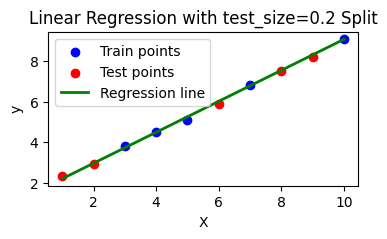

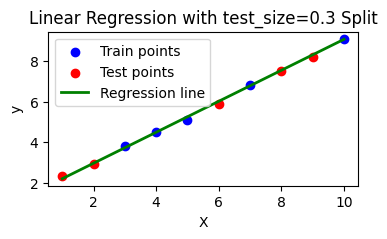

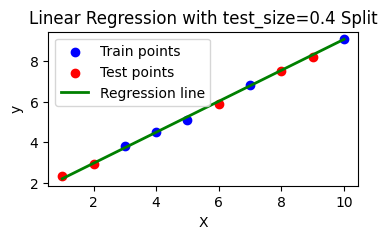

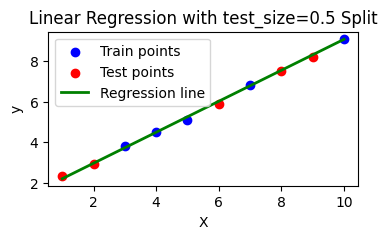

In [21]:
#with builtin
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Example dataset
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([2.3,2.9,3.8,4.5,5.1,5.9,6.8,7.5,8.2,9.1])

# Different test sizes to try
test_sizes = [0.2, 0.3, 0.4, 0.5]

results = []

for ts in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=42)
    
#create and train model 
    model = LinearRegression()
    model.fit(X_train, y_train)
    
#predicton:
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append([ts, mse, rmse, mae, r2])

# Display results in a table
df = pd.DataFrame(results, columns=["Test Size", "MSE", "RMSE", "MAE", "R²"])
print(df)

for ts in test_sizes:
# Plot regression line + points
    plt.figure(figsize=(4,2))

# Training points
    plt.scatter(X_train, y_train, color="blue", label="Train points")

# Test points
    plt.scatter(X_test, y_test, color="red", label="Test points")

# Regression line (use all X for smooth line)
    plt.plot(X, model.predict(X), color="green", linewidth=2, label="Regression line")

    plt.xlabel("X")
    plt.ylabel("y")
    plt.title(f"Linear Regression with test_size={ts} Split")
    plt.legend()
    plt.show()



Test size fraction: 0.3
MSE: 0.009961441688723446
RMSE: 0.09980702224154094
MAE: 0.09867986798679936
R²: 0.9978845451817246


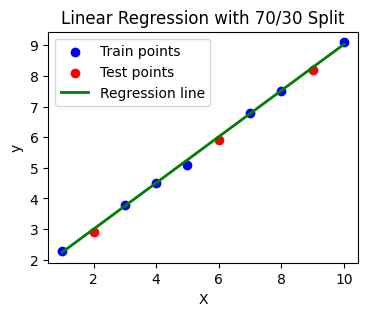

In [23]:
#with builtin 70-30 split
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Example dataset
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([2.3,2.9,3.8,4.5,5.1,5.9,6.8,7.5,8.2,9.1])

# Split data: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("Test size fraction:", len(X_test)/len(X))
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

plt.figure(figsize=(4,3))

# Training points
plt.scatter(X_train, y_train, color="blue", label="Train points")

# Test points
plt.scatter(X_test, y_test, color="red", label="Test points")

# Regression line (use all X for smooth line)
plt.plot(X, model.predict(X), color="green", linewidth=2, label="Regression line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression with 70/30 Split")
plt.legend()
plt.show()

Test size=0.2 | MSE=0.010 | RMSE=0.098 | MAE=0.076 | R²=0.952
Test size=0.3 | MSE=0.011 | RMSE=0.105 | MAE=0.081 | R²=0.974
Test size=0.4 | MSE=0.046 | RMSE=0.214 | MAE=0.202 | R²=0.937
Test size=0.5 | MSE=0.043 | RMSE=0.207 | MAE=0.180 | R²=0.965


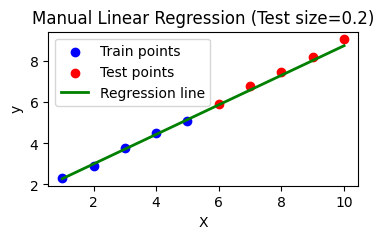

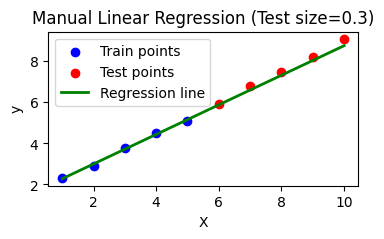

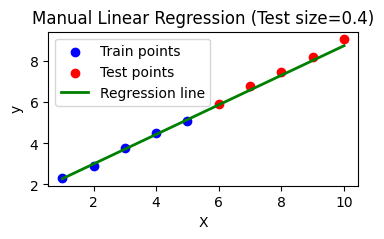

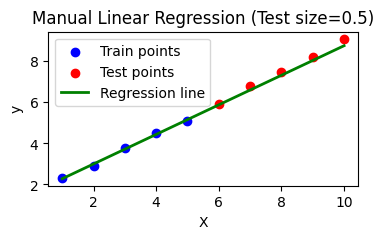

In [25]:
#without builtin
import numpy as np

# Example dataset
X = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2.3,2.9,3.8,4.5,5.1,5.9,6.8,7.5,8.2,9.1])

# Different test sizes to try
test_sizes = [0.2, 0.3, 0.4, 0.5]

results = []

for ts in test_sizes:
    split = int((1 - ts) * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Compute slope and intercept
    x_mean, y_mean = np.mean(X_train), np.mean(y_train)
    m = np.sum((X_train - x_mean)*(y_train - y_mean)) / np.sum((X_train - x_mean)**2)
    c = y_mean - m*x_mean
    
    # Predictions
    y_pred = m*X_test + c
    errors = y_test - y_pred
    
    # Metrics
    mae = np.mean(np.abs(errors))
    mse = np.mean(errors**2)
    rmse = np.sqrt(mse)
    r2 = 1 - np.sum(errors**2)/np.sum((y_test - np.mean(y_test))**2)
    
    results.append([ts, mse, rmse, mae, r2])

# Print results
for r in results:
    print(f"Test size={r[0]} | MSE={r[1]:.3f} | RMSE={r[2]:.3f} | MAE={r[3]:.3f} | R²={r[4]:.3f}")

for ts in test_sizes:
# Plot regression line + points
    plt.figure(figsize=(4,2))
    plt.scatter(X_train, y_train, color="blue", label="Train points")
    plt.scatter(X_test, y_test, color="red", label="Test points")
    plt.plot(X, m*X + c, color="green", linewidth=2, label="Regression line")
    plt.title(f"Manual Linear Regression (Test size={ts})")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()   


Test size: 0.3
MSE: 0.010952380952380858 RMSE: 0.10465362369445626 MAE: 0.08095238095238007 R²: 0.9744633604737234


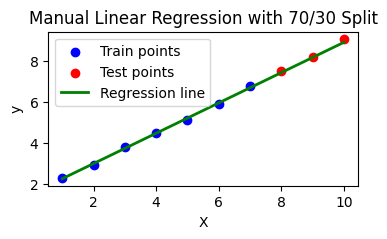

In [30]:
#without builtin 70-30 split
import numpy as np
import matplotlib.pyplot as plt

# Example dataset
X = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2.3,2.9,3.8,4.5,5.1,5.9,6.8,7.5,8.2,9.1])

# Manual holdout: 70% train, 30% test
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Compute slope and intercept using training set
x_mean, y_mean = np.mean(X_train), np.mean(y_train)
m = np.sum((X_train - x_mean)*(y_train - y_mean)) / np.sum((X_train - x_mean)**2)
c = y_mean - m*x_mean

# Predictions
y_pred = m*X_test + c
errors = y_test - y_pred

# Metrics
mae = np.mean(np.abs(errors))
mse = np.mean(errors**2)
rmse = np.sqrt(mse)
r2 = 1 - np.sum(errors**2)/np.sum((y_test - np.mean(y_test))**2)

print("Test size:", len(X_test)/len(X))
print("MSE:", mse, "RMSE:", rmse, "MAE:", mae, "R²:", r2)

# Plot regression line + points
plt.figure(figsize=(4,2))
plt.scatter(X_train, y_train, color="blue", label="Train points")
plt.scatter(X_test, y_test, color="red", label="Test points")
plt.plot(X, m*X + c, color="green", linewidth=2, label="Regression line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Manual Linear Regression with 70/30 Split")
plt.legend()
plt.show()


In [10]:
#print the regression equation explicitly
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Example dataset
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([2.3,2.9,3.8,4.5,5.1,5.9,6.8,7.5,8.2,9.1])

# Split data: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Print regression equation
m = model.coef_[0]        # slope
c = model.intercept_      # intercept
print(f"Regression Equation: y = {m:.3f}x + {c:.3f}")


Regression Equation: y = 0.754x + 1.490
